In [1]:
import pandas as pd
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

In [2]:
# 1. Load Global Data
print("Loading global dataset (this might take a minute)...")
df_global = pd.read_csv('./data/engineered_features_all.csv', parse_dates=['Timestamp'])

Loading global dataset (this might take a minute)...


In [4]:
# 2. Sort chronologically to prevent data leakage during splitting
df_global = df_global.sort_values(['Cell_ID', 'Timestamp'])

In [5]:
# 3. Create Multi-Step Targets (Grouped by Cell to prevent overlap)
print("Generating 1-6 hour targets for all cells...")
horizons = {'1h': 4, '2h': 8, '3h': 12, '4h': 16, '5h': 20, '6h': 24}
target_cols = []

for name, steps in horizons.items():
    col_name = f'target_{name}_ahead'
    df_global[col_name] = df_global.groupby('Cell_ID')['4G data volume DL'].shift(-steps)
    target_cols.append(col_name)

# Drop rows at the end of each cell's timeline that lack future targets
df_global = df_global.dropna()

Generating 1-6 hour targets for all cells...


In [6]:
# 4. Global Time-Based Split
# We find the exact timestamp that represents the 80% mark of our timeline
split_date = df_global['Timestamp'].quantile(0.8)
train_df = df_global[df_global['Timestamp'] <= split_date]
test_df = df_global[df_global['Timestamp'] > split_date]

features = [
    '4G data volume DL', '4G RB utilization', 
    'hour', 'minute', 'day_of_week', 'is_weekend', 
    'vol_lag_1', 'vol_lag_4', 'vol_lag_96'
]

X_train, y_train = train_df[features], train_df[target_cols]
X_test, y_test = test_df[features], test_df[target_cols]

print(f"Training on {len(X_train)} intervals (Dates <= {split_date.date()})")
print(f"Testing on {len(X_test)} intervals (Dates > {split_date.date()})")
print(f"Total Unique Cells in Test Set: {test_df['Cell_ID'].nunique()}")

Training on 688074 intervals (Dates <= 2025-04-25)
Testing on 171885 intervals (Dates > 2025-04-25)
Total Unique Cells in Test Set: 184


In [7]:
# 5. Train the Global Multi-Output Model
print("\nTraining Global XGBoost Multi-Step Forecaster...")
base_xgb = xgb.XGBRegressor(
    n_estimators=100, # Reduced slightly for faster global training
    learning_rate=0.1, 
    max_depth=5, 
    random_state=42,
    tree_method='hist' # Highly optimized for large datasets
)
global_model = MultiOutputRegressor(base_xgb)
global_model.fit(X_train, y_train)


Training Global XGBoost Multi-Step Forecaster...


,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.,"XGBRegressor(...ree=None, ...)"
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary <n_jobs>` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
Name,Type,Value
estimators_ estimators_: list of ``n_output`` estimatorsEstimators used for predictions.,list,"[XGBRegressor(...ree=None, ...), XGBRegressor(...ree=None, ...), XGBRegressor(...ree=None, ...), XGBRegressor(...ree=None, ...), ...]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[<U17](9,)","['4G data volume DL','4G RB utilization','hour',...,'vol_lag_1', 'vol_lag_4','vol_lag_96']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying `estimator` exposes such an attribute when fit... versionadded:: 0.24,int,9
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None


In [8]:
# 6. Predict and Evaluate
print("\nEvaluating Global Model...")
y_pred = global_model.predict(X_test)

mae_scores = []
for i, col in enumerate(target_cols):
    mae = mean_absolute_error(y_test[col], y_pred[:, i])
    mae_scores.append(mae)
    print(f"{col}: {mae:.2f} GB")


Evaluating Global Model...
target_1h_ahead: 198.74 GB
target_2h_ahead: 222.92 GB
target_3h_ahead: 239.23 GB
target_4h_ahead: 251.47 GB
target_5h_ahead: 261.59 GB
target_6h_ahead: 268.69 GB


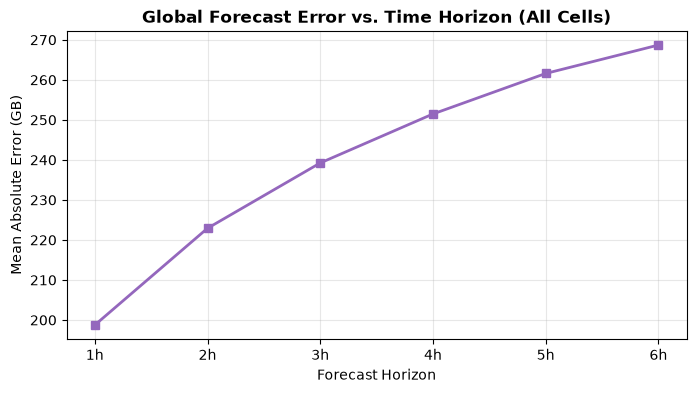

In [9]:
# 7. Plot Global Error Degradation
plt.figure(figsize=(8, 4))
plt.plot(['1h', '2h', '3h', '4h', '5h', '6h'], mae_scores, marker='s', color='tab:purple', linewidth=2)
plt.title("Global Forecast Error vs. Time Horizon (All Cells)", fontweight='bold')
plt.xlabel("Forecast Horizon")
plt.ylabel("Mean Absolute Error (GB)")
plt.grid(True, alpha=0.3)
plt.show()